# **INF3721 - TP 1 : Apprentissage supervisé k-NN**
---


| **Membres du groupe**         | **Matricule**|
|-------------------------------|--------------|
|PRINCE MABENGUE BEBONSU JUNIOR |    22T2832   |
|ETONDE MABONGO ULRICH EDOUARD  |    22U2163   |
|FONAYEN CHRISTIAN ASANGWA      |    23V2370   |


**Objectif :** Prédire la classe de revenus (`Income_Group`) d'un pays à partir de 1516 indicateurs économiques de la Banque Mondiale pour l'année 2023.


---
## **Partie 1 : Extraction et Pré-traitement des données**
Assigné à : PRINCE MABENGUE BEBONSU JUNIOR

Dans cette partie, nous présentons le code développé pour l’extraction automatisée du jeu de données complet, suivi des différentes étapes de prétraitement nécessaires à son exploitation.

In [48]:
import requests
import os
import zipfile
import io

# ----- Dossier de stockage -----
output_folder = "worldbank_data2"
os.makedirs(output_folder, exist_ok=True)

# ----- Récupérer liste des pays -----
url = "http://api.worldbank.org/v2/country?per_page=400&format=json"
response = requests.get(url).json()
countries = response[1]

# ----- Filtrer les agrégats (garder seulement les vrais pays) -----
countries = [c for c in countries if c['region']['value'] != 'Aggregates']

print(f"{len(countries)} vrais pays trouvés")

# ----- Télécharger et décompresser chaque pays -----
for idx, country in enumerate(countries, start=1):
    code = country['id']
    name = country['name']

    print(f"{idx}/{len(countries)} - Téléchargement : {name} ({code})")

    download_url = f"http://api.worldbank.org/v2/country/{code}?downloadformat=csv"

    try:
        r = requests.get(download_url, timeout=30)
        r.raise_for_status()  # lève une erreur si status != 200

        # décompresser ZIP en mémoire pour pouvoir collecter les donnee et charger dans mon data frame
        z = zipfile.ZipFile(io.BytesIO(r.content))

        country_folder = os.path.join(output_folder, code)
        os.makedirs(country_folder, exist_ok=True)

        z.extractall(country_folder)
# Gestion des cas derreurs
    except Exception as e:
        print(f"Erreur lors du téléchargement de {code} : {e}")
        continue

print("✅ Téléchargement terminé pour tous les pays")

217 vrais pays trouvés
1/217 - Téléchargement : Aruba (ABW)
2/217 - Téléchargement : Afghanistan (AFG)
3/217 - Téléchargement : Angola (AGO)
4/217 - Téléchargement : Albania (ALB)
5/217 - Téléchargement : Andorra (AND)
6/217 - Téléchargement : United Arab Emirates (ARE)
7/217 - Téléchargement : Argentina (ARG)
8/217 - Téléchargement : Armenia (ARM)
9/217 - Téléchargement : American Samoa (ASM)
10/217 - Téléchargement : Antigua and Barbuda (ATG)
11/217 - Téléchargement : Australia (AUS)
12/217 - Téléchargement : Austria (AUT)
13/217 - Téléchargement : Azerbaijan (AZE)
14/217 - Téléchargement : Burundi (BDI)
15/217 - Téléchargement : Belgium (BEL)
16/217 - Téléchargement : Benin (BEN)
17/217 - Téléchargement : Burkina Faso (BFA)
18/217 - Téléchargement : Bangladesh (BGD)
19/217 - Téléchargement : Bulgaria (BGR)
20/217 - Téléchargement : Bahrain (BHR)
21/217 - Téléchargement : Bahamas, The (BHS)
22/217 - Téléchargement : Bosnia and Herzegovina (BIH)
23/217 - Téléchargement : Belarus (BLR)

À cette étape, nous construisons le DataFrame permettant le chargement et le prétraitement systématique des données. Cette organisation facilite la gestion des indicateurs et la préparation du jeu de données pour l’analyse.

In [49]:
import pandas as pd
import glob
import os

#  chargement de mon jeu de donnees
data_dir = "worldbank_data2"
all_country_data = []

income_group_map = {c['id'].upper(): c['incomeLevel']['value'] for c in countries if 'incomeLevel' in c and 'value' in c['incomeLevel']}

print("--- Début de la lecture des fichiers ---")

for country_folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, country_folder)
    if not os.path.isdir(folder_path):
        continue

    api_files = glob.glob(os.path.join(folder_path, "API_*.csv"))
    if not api_files:
        continue

    try:
        # Lecture en sautant les lignes d'en-tête (standard Banque Mondiale)
        df = pd.read_csv(api_files[0], skiprows=4)

        # Sélection des colonnes utiles
        df_2023 = df[["Country Code", "Indicator Code", "2023"]].copy()

        # Pivotage : on transforme les indicateurs en colonnes
        pivot = df_2023.pivot(index="Country Code", columns="Indicator Code", values="2023")

        # Ajout de la classe Income_Group
        code_upper = country_folder.upper()
        pivot["Income_Group"] = income_group_map.get(code_upper, "Unknown")

        all_country_data.append(pivot)

    except Exception as e:
        print(f"Erreur sur {country_folder}: {e}")
        continue

print(f"--- Fusion de {len(all_country_data)} pays en cours ---")

# ----- FUSION OPTIMISÉE -----
# pd.concat avec axis=0 aligne automatiquement toutes les colonnes par leur nom.
# Les colonnes manquantes pour certains pays seront automatiquement remplies par des NaN.
final_df = pd.concat(all_country_data, axis=0, sort=True)

# Replacer l'index (Country Code) en colonne classique
final_df.reset_index(inplace=True)

# Déffragmentation finale pour la performance
final_df = final_df.copy()

# ----- VÉRIFICATION -----
print("\n Statistiques finales :")
print(f"Dimensions du dataset : {final_df.shape}")
print(f"Nombre total de valeurs manquantes (NaN) : {final_df.isna().sum().sum()}")
print("\nRépartition des classes :")
print(final_df["Income_Group"].value_counts())

# ----- SAUVEGARDE  finale pour lutilisation future -----
final_df.to_csv("dataset_brut.csv", index=False)
print("\nFichier 'dataset_brut.csv' enregistré avec succès.")

--- Début de la lecture des fichiers ---
--- Fusion de 216 pays en cours ---

 Statistiques finales :
Dimensions du dataset : (216, 1518)
Nombre total de valeurs manquantes (NaN) : 174000

Répartition des classes :
Income_Group
High income            86
Upper middle income    54
Lower middle income    49
Low income             25
Not classified          2
Name: count, dtype: int64

Fichier 'dataset_brut.csv' enregistré avec succès.


Nous appliquons ici une imputation stratifiée sur les valeurs manquantes de notre jeu de données. Cette approche consiste à calculer la médiane au sein de chaque groupe de revenu, ce qui permet de remplacer les valeurs manquantes tout en respectant la cohérence économique des données.

La médiane ainsi calculée est privilégiée par rapport à la moyenne globale, car elle est moins sensible aux valeurs extrêmes et reflète plus fidèlement la tendance centrale des indicateurs pour chaque catégorie de revenu.

In [50]:
import pandas as pd
import numpy as np

# 1. Chargement du jeu de données brut
df = pd.read_csv("dataset_brut.csv")

# 2. Séparation des colonnes
# Identifiants et Cible
cols_id = ['Country Code', 'Income_Group']
# Tous les autres sont des indicateurs numériques (1516 colonnes théoriques)
cols_indicators = [col for col in df.columns if col not in cols_id]

print(f"Colonnes à traiter : {len(cols_indicators)}")
print(f"NaN avant traitement : {df[cols_indicators].isna().sum().sum()}")

# 3. Étape A : Remplacer les NaN par la MÉDIANE DU GROUPE (Income_Group)
# Note : On ignore les pays où Income_Group est "Unknown" ou NaN pour cette étape
df[cols_indicators] = df.groupby('Income_Group')[cols_indicators].transform(
    lambda x: x.fillna(x.median())
)

# 4. Étape B : Remplacer les NaN restants par la MÉDIANE GÉNÉRALE
# (Cas où un indicateur est vide pour TOUTE une catégorie de revenu)
df[cols_indicators] = df[cols_indicators].fillna(df[cols_indicators].median())

# 5. Gestion de la colonne Income_Group (La Classe)
# Si la classe elle-même est manquante ou "Unknown", on supprime ces lignes
# car on ne peut pas entraîner un modèle supervisé sans étiquette réelle.
df = df[df['Income_Group'] != 'Not classified']
df = df.dropna(subset=['Income_Group'])

# 6. Encodage de la classe pour le k-NN (Prêt pour l'étape 5)
# Ordre logique : Low -> Lower Middle -> Upper Middle -> High
income_order = {
    'Low income': 0,
    'Lower middle income': 1,
    'Upper middle income': 2,
    'High income': 3
}

# 7. Sauvegarde du jeu de données traité
df.to_csv("dataset_traite.csv", index=False)
df.describe()

print("\n--- Traitement Terminé ---")
print(f"Dimensions finales : {df.shape}")
print(f"NaN restants : {df.isna().sum().sum()}")
print(f"Fichier sauvegardé : dataset_traite.csv")

Colonnes à traiter : 1516
NaN avant traitement : 174000

--- Traitement Terminé ---
Dimensions finales : (214, 1518)
NaN restants : 74044
Fichier sauvegardé : dataset_traite.csv


---
## **Partie 2 : Analyse Statistique et Decoupage**
Assigné à : ETONDE MABONGO ULRICH EDOUARD

### **2.1. Importation des bibliothèques**

Nous commençons par importer les bibliothèques nécessaires pour l'analyse exploratoire des données (EDA) et la visualisation.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **2.2. Exploration initiale du jeu de données**

Chargement du jeu de données traité précédemment pour vérifier sa structure et s'assurer que l'imputation a été effectuée correctement.

In [52]:
# Chargement du Jeu de données
data = pd.read_csv('dataset_traite.csv')

#Montrons les donnees
data.head()

,Country Code,AG.CON.FERT.PT.ZS,AG.CON.FERT.ZS,AG.LND.AGRI.K2,AG.LND.AGRI.ZS,AG.LND.ARBL.HA,AG.LND.ARBL.HA.PC,AG.LND.ARBL.ZS,AG.LND.CREL.HA,AG.LND.CROP.ZS,...,per_sa_allsa.cov_q4_tot,per_sa_allsa.cov_q5_tot,per_si_allsi.adq_pop_tot,per_si_allsi.ben_q1_tot,per_si_allsi.cov_pop_tot,per_si_allsi.cov_q1_tot,per_si_allsi.cov_q2_tot,per_si_allsi.cov_q3_tot,per_si_allsi.cov_q4_tot,per_si_allsi.cov_q5_tot
0,BLZ,204.921920,337.540000,1820.00,7.978957,100000.0,0.243246,4.384042,41522.0,1.402893,...,55.881926,31.021822,31.024722,1.206603,23.39882,8.038775,17.507218,25.708303,30.444992,35.280713
1,ALB,204.921920,66.084307,10446.00,38.124088,590700.0,0.244688,21.558394,135654.0,3.204380,...,55.881926,31.021822,31.024722,1.206603,23.39882,8.038775,17.507218,25.708303,30.444992,35.280713
2,PYF,77.731870,130.400000,300.65,8.661769,2500.0,0.008893,0.720254,324650.0,7.490637,...,55.881926,31.021822,31.024722,1.206603,23.39882,8.038775,17.507218,25.708303,30.444992,35.280713
3,IRN,58.693462,68.289445,470670.00,29.008937,15699000.0,0.173261,9.675809,8661544.0,1.165485,...,55.881926,31.021822,31.024722,1.206603,23.39882,8.038775,17.507218,25.708303,30.444992,35.280713
4,KIR,87.718901,0.000000,340.00,41.975309,2000.0,0.015091,2.469136,1106692.5,39.506173,...,55.881926,31.021822,31.024722,1.206603,23.39882,8.038775,17.507218,25.708303,30.444992,35.280713


### **2.3. Analyse de la distribution des classes**

Il est crucial de vérifier si nos classes (`Income_Group`) sont équilibrées. Un déséquilibre important pourrait influencer la performance du modèle k-NN.

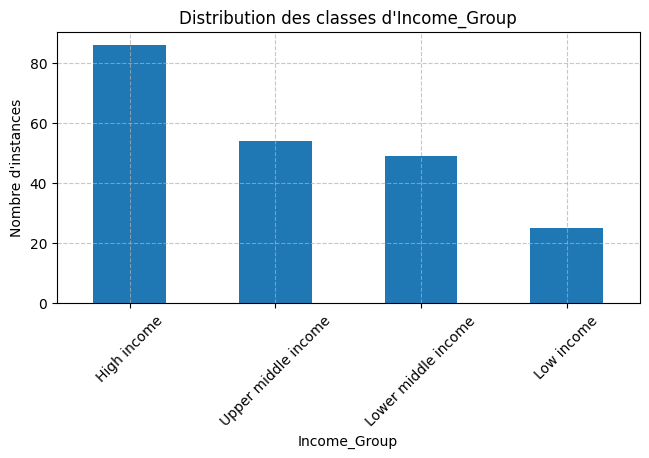

In [53]:
data['Income_Group'].value_counts().plot(kind='bar')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.title('Distribution des classes d\'Income_Group')
plt.xlabel('Income_Group')
plt.ylabel('Nombre d\'instances')
plt.xticks(rotation=45)
plt.show()

### **2.4. Statistiques descriptives des indicateurs**

Cette étape permet d'observer la dispersion, la moyenne et les valeurs extrêmes des 1516 indicateurs économiques avant tout filtrage supplémentaire.

In [54]:
indicators = data.drop(columns=['Income_Group', 'Country Code']).columns
data[indicators].describe()

,AG.CON.FERT.PT.ZS,AG.CON.FERT.ZS,AG.LND.AGRI.K2,AG.LND.AGRI.ZS,AG.LND.ARBL.HA,AG.LND.ARBL.HA.PC,AG.LND.ARBL.ZS,AG.LND.CREL.HA,AG.LND.CROP.ZS,AG.LND.EL5M.RU.K2,...,per_sa_allsa.cov_q4_tot,per_sa_allsa.cov_q5_tot,per_si_allsi.adq_pop_tot,per_si_allsi.ben_q1_tot,per_si_allsi.cov_pop_tot,per_si_allsi.cov_q1_tot,per_si_allsi.cov_q2_tot,per_si_allsi.cov_q3_tot,per_si_allsi.cov_q4_tot,per_si_allsi.cov_q5_tot
count,214.000000,214.000000,2.140000e+02,214.000000,2.140000e+02,214.000000,214.000000,2.140000e+02,214.000000,0.0,...,2.140000e+02,2.140000e+02,2.140000e+02,2.140000e+02,2.140000e+02,2.140000e+02,2.140000e+02,2.140000e+02,2.140000e+02,2.140000e+02
mean,299.128875,148.548340,2.132670e+05,36.724850,5.656404e+06,0.172524,13.498009,2.985897e+06,4.320045,NaN,...,5.588193e+01,3.102182e+01,3.102472e+01,1.206603e+00,2.339882e+01,8.038775e+00,1.750722e+01,2.570830e+01,3.044499e+01,3.528071e+01
std,1461.035549,279.094714,6.043398e+05,22.415883,1.666590e+07,0.213033,13.352587,9.041662e+06,7.671554,NaN,...,8.546505e-14,1.460028e-13,5.341565e-14,4.451305e-15,1.068313e-13,1.780522e-15,3.561044e-14,8.190400e-14,1.780522e-14,1.353197e-13
min,0.194743,0.000000,3.000000e+00,0.445038,7.000000e+01,0.000095,0.051095,0.000000e+00,0.003529,NaN,...,5.588193e+01,3.102182e+01,3.102472e+01,1.206603e+00,2.339882e+01,8.038775e+00,1.750722e+01,2.570830e+01,3.044499e+01,3.528071e+01
25%,77.731870,26.766250,2.010275e+03,19.044090,7.545000e+04,0.043712,3.301645,1.592838e+05,0.415652,NaN,...,5.588193e+01,3.102182e+01,3.102472e+01,1.206603e+00,2.339882e+01,8.038775e+00,1.750722e+01,2.570830e+01,3.044499e+01,3.528071e+01
50%,87.718901,93.661528,2.517650e+04,36.914213,9.888198e+05,0.100892,9.120766,3.842605e+05,1.411181,NaN,...,5.588193e+01,3.102182e+01,3.102472e+01,1.206603e+00,2.339882e+01,8.038775e+00,1.750722e+01,2.570830e+01,3.044499e+01,3.528071e+01
75%,204.921920,155.540589,1.460309e+05,53.248792,4.040250e+06,0.218082,19.727445,1.970411e+06,4.770068,NaN,...,5.588193e+01,3.102182e+01,3.102472e+01,1.206603e+00,2.339882e+01,8.038775e+00,1.750722e+01,2.570830e+01,3.044499e+01,3.528071e+01
max,20163.269945,2926.428663,5.204130e+06,86.475816,1.515635e+08,1.459397,60.627789,9.998726e+07,60.000000,NaN,...,5.588193e+01,3.102182e+01,3.102472e+01,1.206603e+00,2.339882e+01,8.038775e+00,1.750722e+01,2.570830e+01,3.044499e+01,3.528071e+01


### **2.5. Nettoyage et filtrage des colonnes**

Certains indicateurs comportent encore trop de valeurs manquantes malgré l'imputation initiale, ou ne varient pas assez. Nous filtrons les colonnes ayant plus de 50% de valeurs manquantes pour ne garder que les variables les plus informatives.

In [55]:
# Calcul du taux de remplissage
missing_pct = data.isna().mean().sort_values(ascending=False)

# Identification des colonnes trop vides
seuil_nan = 0.5
cols_trop_nan = missing_pct[missing_pct > seuil_nan].index.tolist()

# Identification des colonnes constantes
numeric_cols = data.select_dtypes(include=[np.number]).columns
variance_zero = data[numeric_cols].columns[data[numeric_cols].nunique() <= 1].tolist()

# Fusion des listes de colonnes à supprimer
cols_to_drop = list(set(cols_trop_nan + variance_zero))
print(f"Colonnes supprimées (NaN > {seuil_nan*100}%): {len(cols_trop_nan)}")
print(f"Colonnes supprimées (Constantes/Zero Var): {len(variance_zero)}")

# 5. Création du dataset propre
data_prepared = data.drop(columns=cols_to_drop)

# Imputation finale par la médiane sur les colonnes restantes
for col in data_prepared.select_dtypes(include=[np.number]).columns:
    data_prepared[col] = data_prepared[col].fillna(data_prepared[col].median())

print(f"\nDimensions après nettoyage : {data_prepared.shape}")

Colonnes supprimées (NaN > 50.0%): 346
Colonnes supprimées (Constantes/Zero Var): 386

Dimensions après nettoyage : (214, 1132)


### **2.6. Préparation finale et Standardisation**

Avant de passer à la modélisation, nous vérifions l'absence totale de valeurs nulles et nous préparons le dataset final.

In [56]:
print(f"Colonnes et valeurs manquantes apres imputation :\n{data_prepared.isna().sum()}")
data_prepared.describe()

Colonnes et valeurs manquantes apres imputation :
Country Code         0
AG.CON.FERT.PT.ZS    0
AG.CON.FERT.ZS       0
AG.LND.AGRI.K2       0
AG.LND.AGRI.ZS       0
                    ..
VC.IDP.NWCV          0
VC.IDP.NWDS          0
VC.IHR.PSRC.FE.P5    0
VC.IHR.PSRC.MA.P5    0
VC.IHR.PSRC.P5       0
Length: 1132, dtype: int64


,AG.CON.FERT.PT.ZS,AG.CON.FERT.ZS,AG.LND.AGRI.K2,AG.LND.AGRI.ZS,AG.LND.ARBL.HA,AG.LND.ARBL.HA.PC,AG.LND.ARBL.ZS,AG.LND.CREL.HA,AG.LND.CROP.ZS,AG.LND.FRST.K2,...,VA.PER.RNK,VA.PER.RNK.LOWER,VA.PER.RNK.UPPER,VA.STD.ERR,VC.BTL.DETH,VC.IDP.NWCV,VC.IDP.NWDS,VC.IHR.PSRC.FE.P5,VC.IHR.PSRC.MA.P5,VC.IHR.PSRC.P5
count,214.000000,214.000000,2.140000e+02,214.000000,2.140000e+02,214.000000,214.000000,2.140000e+02,214.000000,2.140000e+02,...,214.000000,214.000000,214.000000,214.000000,214.000000,2.140000e+02,2.140000e+02,214.000000,214.000000,214.000000
mean,299.128875,148.548340,2.132670e+05,36.724850,5.656404e+06,0.172524,13.498009,2.985897e+06,4.320045,1.823844e+05,...,51.850834,44.949147,58.450156,0.139368,779.095794,1.655438e+05,1.210614e+05,1.907257,10.276760,5.984827
std,1461.035549,279.094714,6.043398e+05,22.415883,1.666590e+07,0.213033,13.352587,9.041662e+06,7.671554,7.456297e+05,...,28.861401,27.446526,29.984091,0.041885,5444.207020,5.409740e+05,5.046186e+05,1.774438,16.350133,8.866512
min,0.194743,0.000000,3.000000e+00,0.445038,7.000000e+01,0.000095,0.051095,0.000000e+00,0.003529,0.000000e+00,...,0.000000,0.000000,2.450980,0.104813,1.000000,2.300000e+02,1.000000e+00,0.071513,0.066836,0.069095
25%,77.731870,26.766250,2.010275e+03,19.044090,7.545000e+04,0.043712,3.301645,1.592838e+05,0.415652,1.412825e+03,...,27.083334,22.181372,31.985294,0.118495,86.750000,1.100000e+04,1.200000e+03,0.668880,1.187730,0.893457
50%,87.718901,93.661528,2.517650e+04,36.914213,9.888198e+05,0.100892,9.120766,3.842605e+05,1.411181,1.966141e+04,...,53.676472,44.607841,59.313725,0.125568,197.000000,1.315000e+05,4.900000e+03,1.854008,6.695281,4.347591
75%,204.921920,155.540589,1.460309e+05,53.248792,4.040250e+06,0.218082,19.727445,1.970411e+06,4.770068,8.610171e+04,...,79.166668,69.607841,87.990196,0.133154,300.500000,1.315000e+05,3.575000e+04,1.941857,10.430602,5.915035
max,20163.269945,2926.428663,5.204130e+06,86.475816,1.515635e+08,1.459397,60.627789,9.998726e+07,60.000000,8.153120e+06,...,100.000000,96.078430,100.000000,0.290148,75080.000000,6.039000e+06,4.702000e+06,11.559439,124.955373,64.160144


In [57]:
indicators = data_prepared.drop(columns=['Income_Group', 'Country Code']).columns
data_prepared[indicators]

,AG.CON.FERT.PT.ZS,AG.CON.FERT.ZS,AG.LND.AGRI.K2,AG.LND.AGRI.ZS,AG.LND.ARBL.HA,AG.LND.ARBL.HA.PC,AG.LND.ARBL.ZS,AG.LND.CREL.HA,AG.LND.CROP.ZS,AG.LND.FRST.K2,...,VA.PER.RNK,VA.PER.RNK.LOWER,VA.PER.RNK.UPPER,VA.STD.ERR,VC.BTL.DETH,VC.IDP.NWCV,VC.IDP.NWDS,VC.IHR.PSRC.FE.P5,VC.IHR.PSRC.MA.P5,VC.IHR.PSRC.P5
0,204.921920,337.540000,1820.000,7.978957,100000.0,0.243246,4.384042,41522.0,1.402893,12435.700,...,63.725491,56.862743,72.549019,0.150875,74.0,11000.0,6700.0,1.941857,10.430602,5.915035
1,204.921920,66.084307,10446.000,38.124088,590700.0,0.244688,21.558394,135654.0,3.204380,7889.000,...,53.921570,45.588234,59.313725,0.123266,74.0,11000.0,13.0,0.844149,1.942300,1.387083
2,77.731870,130.400000,300.650,8.661769,2500.0,0.008893,0.720254,324650.0,7.490637,1494.600,...,79.166668,70.588234,87.990196,0.126383,197.0,131500.0,1200.0,0.668880,1.187730,0.893457
3,58.693462,68.289445,470670.000,29.008937,15699000.0,0.173261,9.675809,8661544.0,1.165485,107883.856,...,7.843137,4.411765,14.705882,0.126459,34.0,11000.0,124000.0,1.941857,10.430602,5.915035
4,87.718901,0.000000,340.000,41.975309,2000.0,0.015091,2.469136,1106692.5,39.506173,11.800,...,84.313728,69.117645,96.078430,0.266198,300.5,73350.0,9800.0,1.854008,6.695281,4.347591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,58.989468,89.525299,50830.460,55.698510,4144147.0,0.432034,45.410333,2405570.0,1.643294,20486.441,...,59.313725,54.411766,62.745098,0.104813,197.0,131500.0,66.0,0.615277,0.839056,0.722658
210,87.718901,27.065000,388120.000,47.142562,800000.0,0.269988,0.971711,339089.0,0.014576,64258.700,...,66.176468,60.294117,72.058823,0.118608,300.5,73350.0,650.0,1.854008,6.695281,4.347591
211,51.009503,93.802866,28730.000,45.894569,2303000.0,0.801996,36.789137,1344490.0,0.527157,22054.074,...,81.862747,75.980392,89.215683,0.105338,197.0,131500.0,1200.0,1.790100,3.566643,2.627800
212,324.290280,0.187206,283472.333,44.858186,2489233.3,0.216768,3.939097,1104151.0,0.134509,71570.000,...,2.941176,0.000000,8.823529,0.163314,513.0,282000.0,167000.0,3.003996,15.043976,8.973089


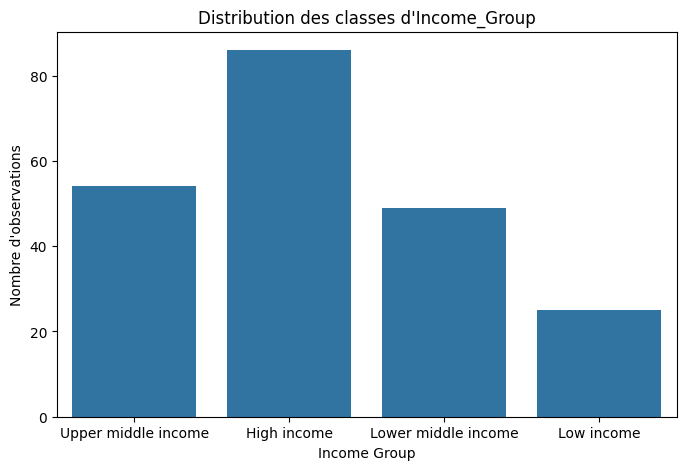

In [58]:
# Distribution des classes
plt.figure(figsize=(8, 5))
sns.countplot(x='Income_Group', data=data_prepared)
plt.title('Distribution des classes d\'Income_Group')
plt.xlabel('Income Group')
plt.ylabel('Nombre d\'observations')
plt.show()

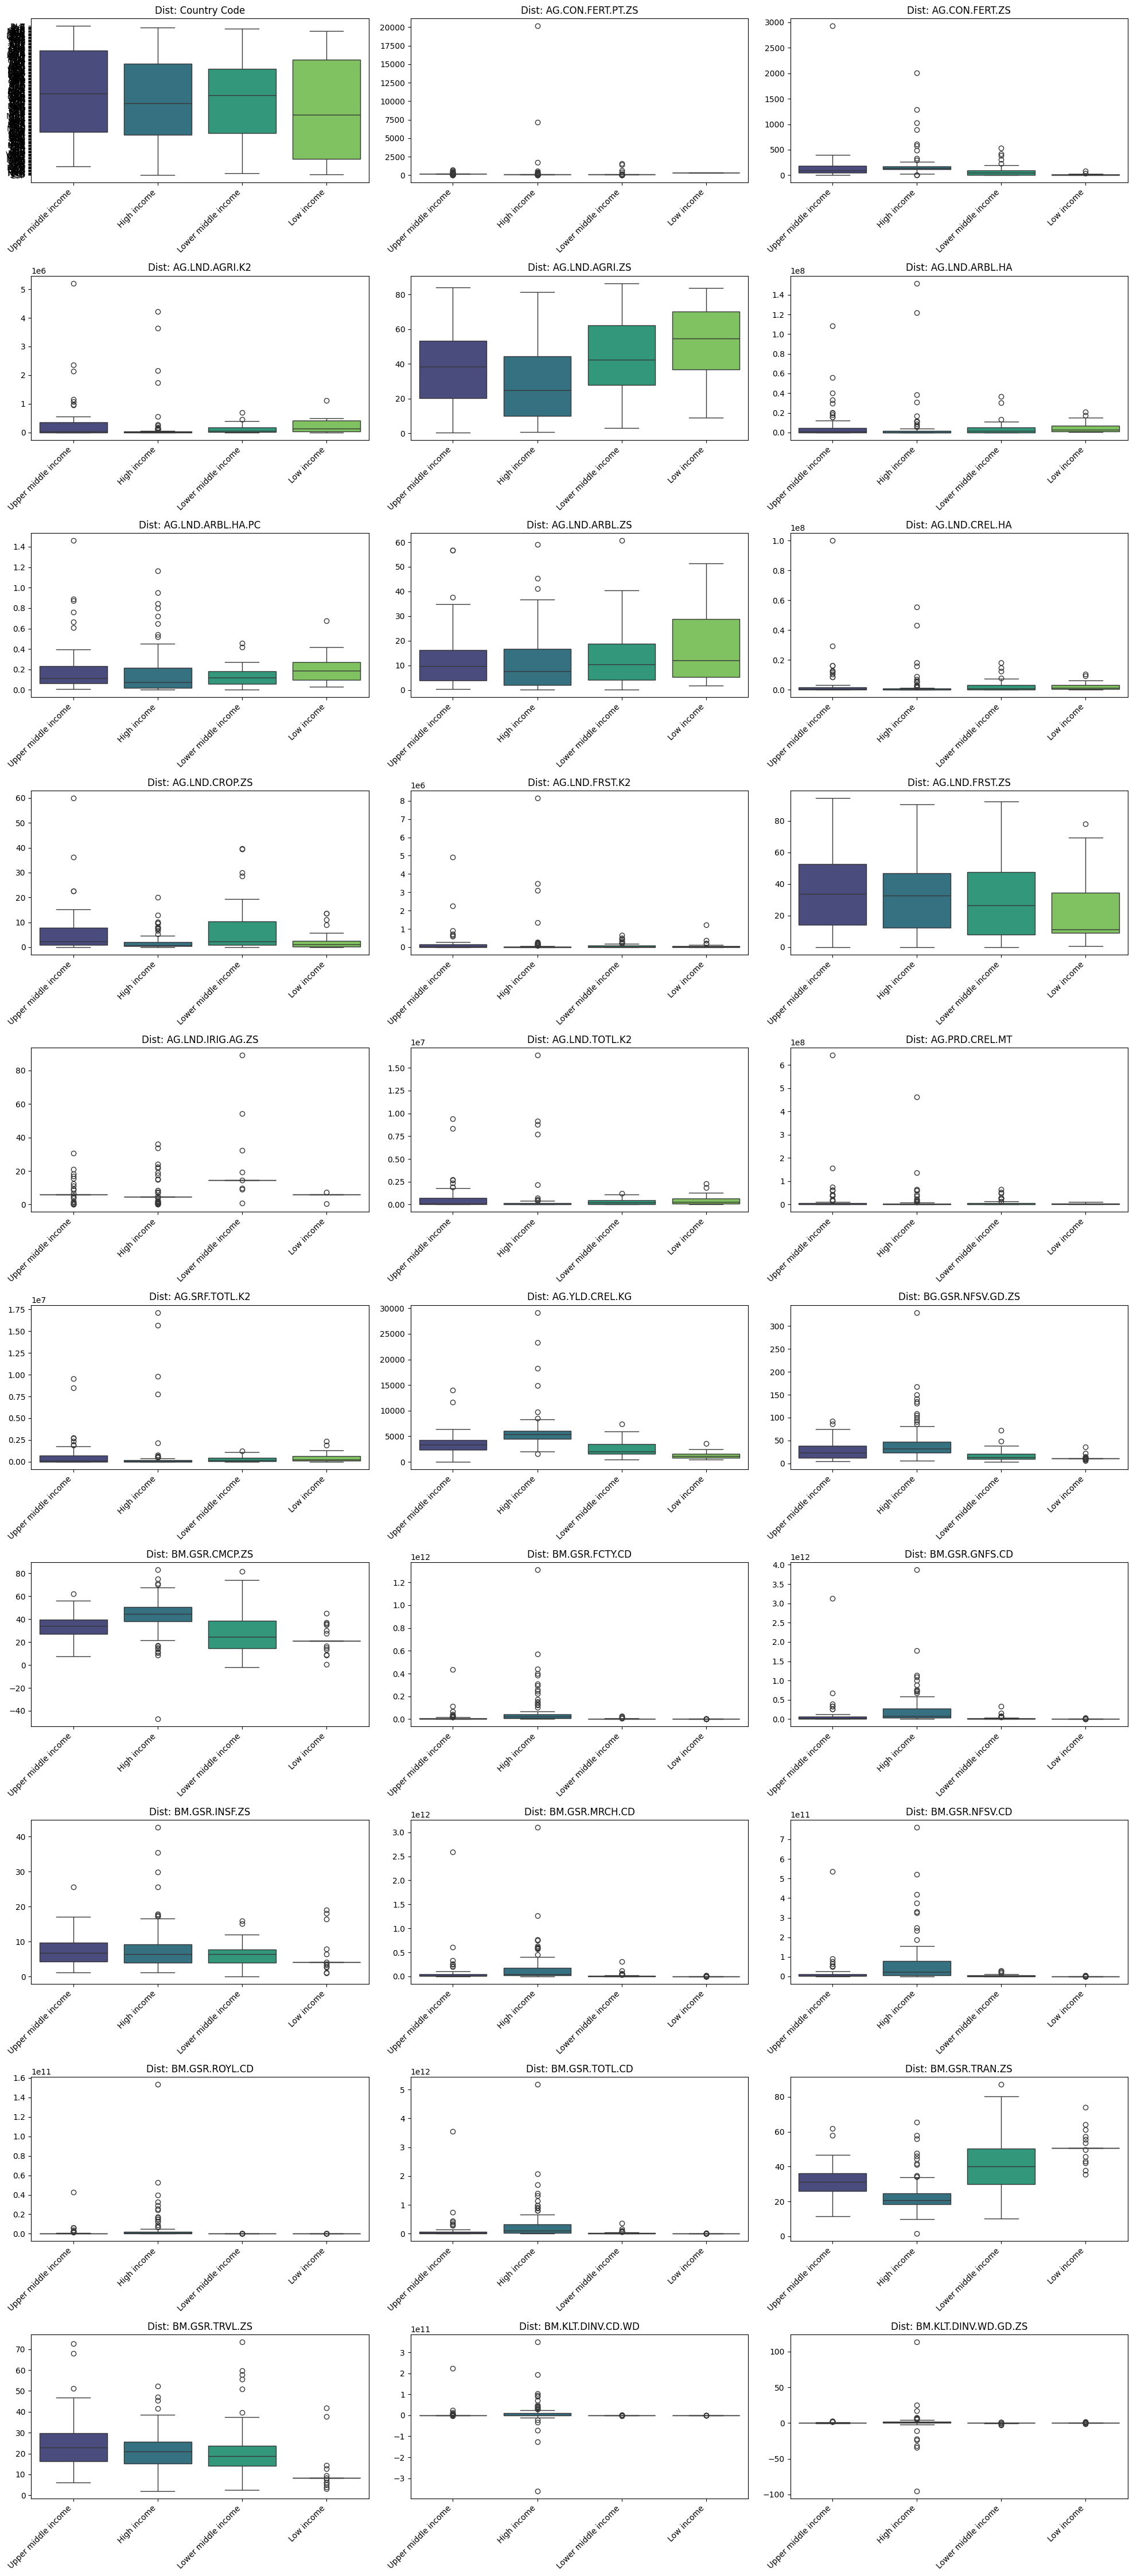

In [59]:
# Sélection de 30 indicateurs pour une vue d'ensemble
indicators_to_plot = data_prepared.columns[:30]

# Configuration de la grille d'affichage (10 lignes, 3 colonnes)
n_cols = 3
n_rows = 10
plt.figure(figsize=(20, 45))

for i, col in enumerate(indicators_to_plot, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x='Income_Group', y=col, data=data_prepared, hue='Income_Group', palette='viridis', legend=False)
    plt.title(f'Dist: {col}', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

Les boîtes à moustaches montrent que les médianes diffèrent nettement selon le groupe de revenu. Malgré l'imputation, certains indicateurs conservent des valeurs extrêmes.
On observe que la majorité des indicateurs présentent des paliers distincts entre 'Low' et 'High income'.


### **2.7. Découpage**

Nous divisons donc nos données en deux ensembles :
1. **Entraînement (80%)** : Pour permettre au modèle d'apprendre les relations.
2. **Test (20%)** : Pour évaluer la capacité de généralisation.

L'utilisation de `groupby('Income_Group').sample` garantit que la proportion de chaque classe est préservée dans les deux échantillons tou

In [60]:
from sklearn.preprocessing import StandardScaler

# Découpage initial
df_train = data_prepared.groupby('Income_Group').sample(frac=0.8, random_state=42)
df_test = data_prepared.drop(df_train.index)

# Séparation X/y
X_train_raw = df_train.drop(columns=['Country Code', 'Income_Group'])
y_train = df_train['Income_Group'].values

X_test_raw = df_test.drop(columns=['Country Code', 'Income_Group'])
y_test = df_test['Income_Group'].values

# Correction des valeurs extremes via Standardisation
# On ajuste le scaler uniquement sur le train pour éviter les fuites de données
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Taille du jeu d'entraînement : {X_train.shape[0]} observations")
print(f"Taille du jeu de test : {X_test.shape[0]} observations")

Taille du jeu d'entraînement : 171 observations
Taille du jeu de test : 43 observations


### **2.8. Validation de la Standardisation**

Le k-NN étant basé sur le calcul de distances, il est sensible à l'échelle des variables. Nous utilisons `StandardScaler` pour que chaque indicateur ait une moyenne de 0 et un écart-type de 1. Comparons maintenant les statistiques entre le train et le test.

In [61]:
# Calcul des statistiques par colonne (axis=0)
comparaison = pd.DataFrame({
    "Moyenne train": X_train.mean(axis=0),
    "Moyenne test": X_test.mean(axis=0),
    "Ecart-type train": X_train.std(axis=0),
    "Ecart-type test": X_test.std(axis=0)
}, index=X_train_raw.columns)

# Calcul des différences
comparaison['Différence Moyenne'] = comparaison['Moyenne train'] - comparaison['Moyenne test']
comparaison['Différence Ecart-type'] = comparaison['Ecart-type train'] - comparaison['Ecart-type test']

comparaison.head()

,Moyenne train,Moyenne test,Ecart-type train,Ecart-type test,Différence Moyenne,Différence Ecart-type
AG.CON.FERT.PT.ZS,3.116416e-17,-0.085046,1.0,0.152454,0.085046,0.847546
AG.CON.FERT.ZS,1.558208e-17,-0.097201,1.0,0.453874,0.097201,0.546126
AG.LND.AGRI.K2,5.194026e-18,-0.054165,1.0,0.391878,0.054165,0.608122
AG.LND.AGRI.ZS,-1.973730e-16,0.198849,1.0,1.030923,-0.198849,-0.030923
AG.LND.ARBL.HA,-5.908204e-17,-0.015733,1.0,0.506013,0.015733,0.493987


### **2.9. Visualisation de la cohérence Train/Test**

Les graphiques suivants permettent de confirmer visuellement que les données de test suivent une distribution similaire à celles d'entraînement, validant ainsi notre méthode de découpage.

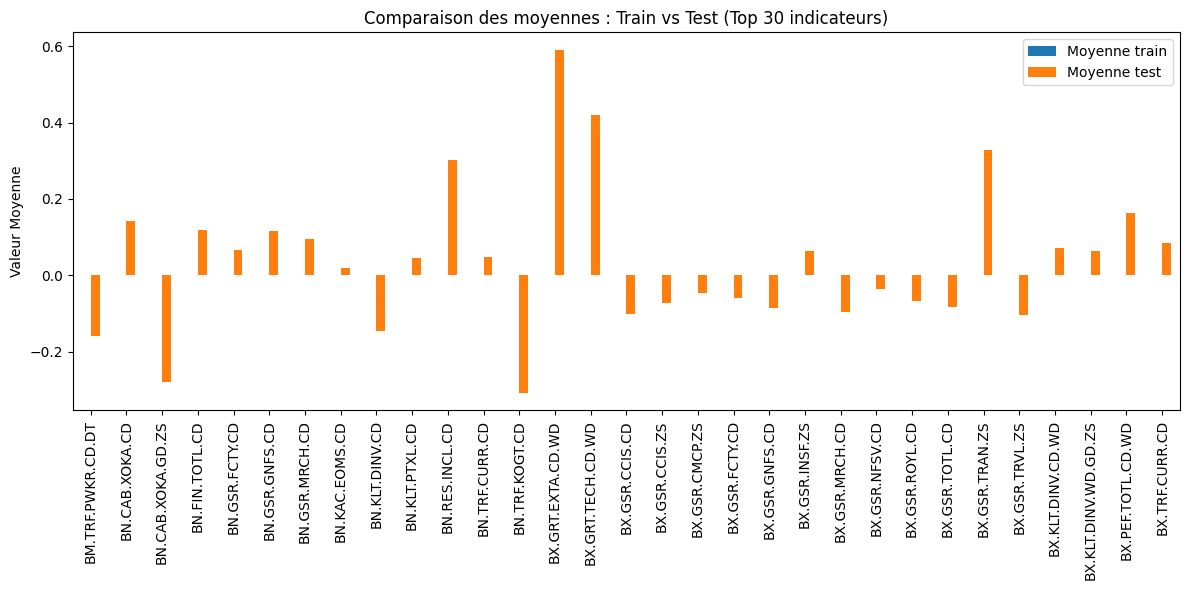

In [62]:
# Sélection d'un échantillon d'indicateurs pour la lisibilité
sample_indicators = comparaison.index[30:61]

# Tracer la comparaison des moyennes
plt.figure(figsize=(12, 6))
comparaison.loc[sample_indicators, ['Moyenne train', 'Moyenne test']].plot(kind='bar', ax=plt.gca())
plt.title('Comparaison des moyennes : Train vs Test (Top 30 indicateurs)')
plt.ylabel('Valeur Moyenne')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

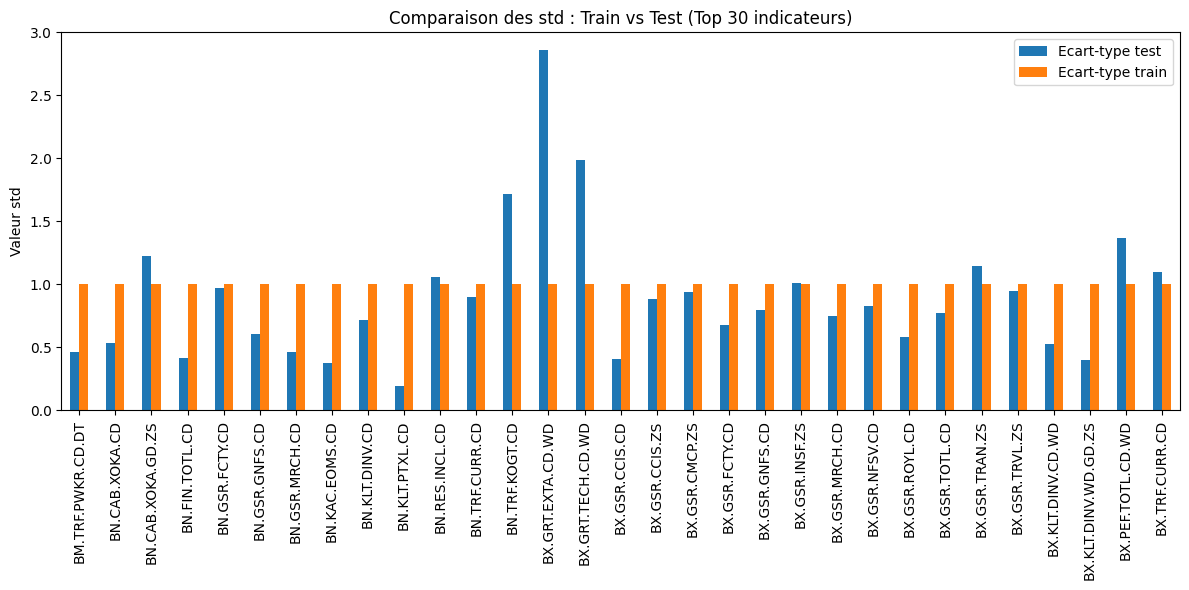

In [63]:
# Sélection d'un échantillon d'indicateurs pour la lisibilité
sample_indicators = comparaison.index[30:61]

# Tracer la comparaison des ecarts-type
plt.figure(figsize=(12, 6))
comparaison.loc[sample_indicators, ['Ecart-type test', 'Ecart-type train']].plot(kind='bar', ax=plt.gca())
plt.title('Comparaison des std : Train vs Test (Top 30 indicateurs)')
plt.ylabel('Valeur std')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

---
## **Partie 3 : Modélisation k-NN et Évaluation**
Assigné à : FONAYEN CHRISTIAN ASANGWA

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

### Distance function definitions
#### -> the goal is to find amongs distance funtions the function that give clearly the distance between to data points

**Eucledian Distance definition**
$$
d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
$$

In [65]:
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point2 - point1) ** 2))

**Manhattab Distance Definition**
$$
d(x, y) = \sum_{i=1}^{n} |x_i - y_i|
$$

In [66]:
def manhattan_distance(point1, point2):
    return np.sum(np.abs(point2 - point1))

**Minkowski Distance definition**
$$
d(x, y) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{\frac{1}{p}}
$$

In [67]:
def Minkowski_distance(point1, point2, p):
    return np.sum(np.abs(point2 - point1) ** p) ** (1/p)

### Select two arbitrary data points from X_train in order to find best distance defition

In [68]:

point_a = X_train[0]
point_b = X_train[1]

#  Euclidean Distance
euclidean_dist = euclidean_distance(point_a, point_b)
print(f"Euclidean Distance: {euclidean_dist:.4f}")

#  Manhattan Distance
manhattan_dist = manhattan_distance(point_a, point_b)
print(f"Manhattan Distance: {manhattan_dist:.4f}")

#  Minkowski Distance (let's use p=3 for this example)
minkowski_dist_p3 = Minkowski_distance(point_a, point_b, p=3)
print(f"Minkowski Distance (p=3): {minkowski_dist_p3:.4f}")

# Minkowski Distance p=5
minkowski_dist_p5 = Minkowski_distance(point_a, point_b, p=5)
print(f"Minkowski Distance (p=5): {minkowski_dist_p5:.4f}")

Euclidean Distance: 19.3294
Manhattan Distance: 263.6925
Minkowski Distance (p=3): 9.1850
Minkowski Distance (p=5): 5.6303


**bold text** We can see that Manhattan is the best for these data set now we ploting graph to apriciat distance

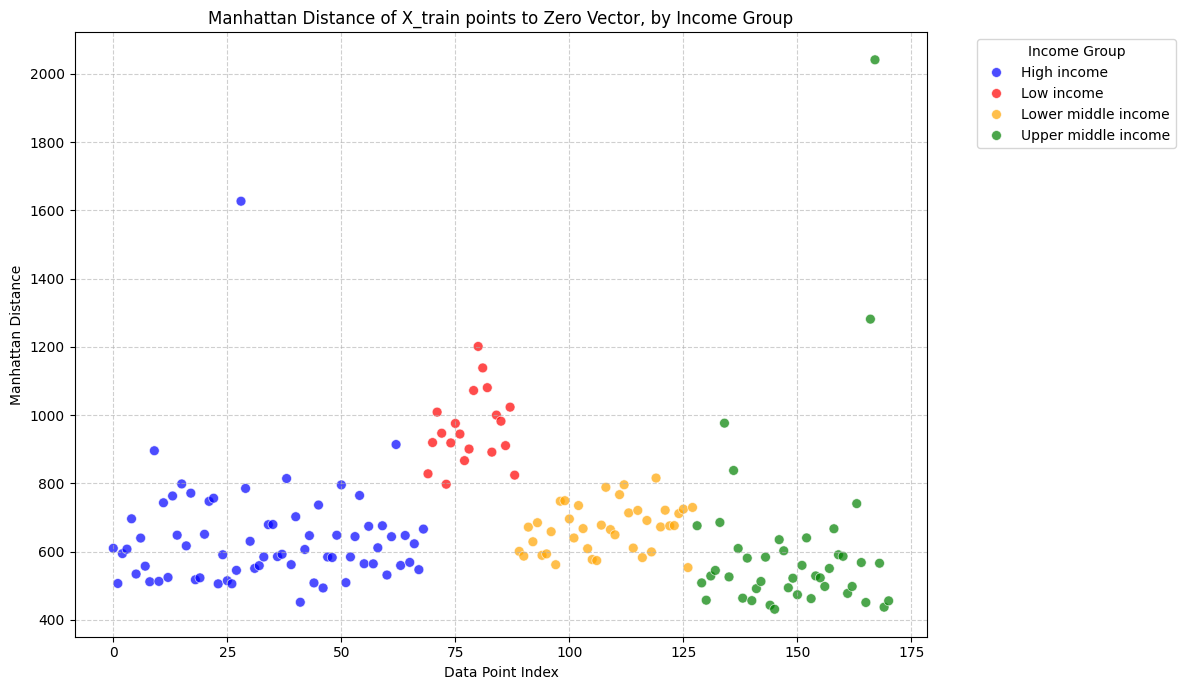

In [69]:
import seaborn as sns

initial_point_zero = np.zeros(X_train.shape[1]) # Define the initial point
manhattan_distances = np.array([manhattan_distance(point, initial_point_zero) for point in X_train])

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Manhattan Distance to Zero': manhattan_distances,
    'Income_Group': y_train
})

custom_color_map = {
    'Low income': 'red',
    'Lower middle income': 'orange',
    'Upper middle income': 'green',
    'High income': 'blue'
}

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=plot_df,
    x=plot_df.index, # Use index to represent individual data points
    y='Manhattan Distance to Zero',
    hue='Income_Group', # Color points by Income_Group
    palette=custom_color_map,  # Use the custom color map
    s=50, # Size of points
    alpha=0.7 # Transparency of points
)
plt.title('Manhattan Distance of X_train points to Zero Vector, by Income Group')
plt.xlabel('Data Point Index')
plt.ylabel('Manhattan Distance')
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### KNN Class

Implements **K-Nearest Neighbors (KNN)** algorithm.

- `__init__(k=3)`: Initializes the model with a chosen number of neighbors \(k\).
- `fit(X, y)`: Stores the training data (`Xtrain`) and corresponding labels (`ytrain`).
- `predict(new_points)`: Predicts labels for multiple new data points by calling `predict_class` on each.
- `predict_class(new_point)`:
  1. Computes the distance between the new point and all training points using the **Minkowski distance** with \(p=5\).
  2. Sorts the distances and selects the indices of the \(k\) nearest neighbors.
  3. Retrieves their labels.
  4. Uses majority voting (via `Counter`) to return the most common label.

**Summary:**  
The model classifies a new point based on the most frequent label among its \(k\) closest neighbors.

In [70]:
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self,X,y):
        self.Xtrain = X
        self.ytrain = y

    def predict(self, new_points):
        predictions = [self.predict_class(new_point) for new_point in new_points]
        return np.array(predictions)

    def predict_class(self, new_point):
        distances = np.array([manhattan_distance(new_point, point) for point in self.Xtrain])

        k_nearest_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.ytrain[i] for i in k_nearest_indices]

        most_common = Counter(k_nearest_labels).most_common(1)[0][0]
        return most_common

### Initializing KNN object and testing Accuracy with test data  

In [71]:
knn = KNN(k=12)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
accuracy = np.mean(predictions == y_test) * 100
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 100.00%


### Adding Predicted point on Graph of training points

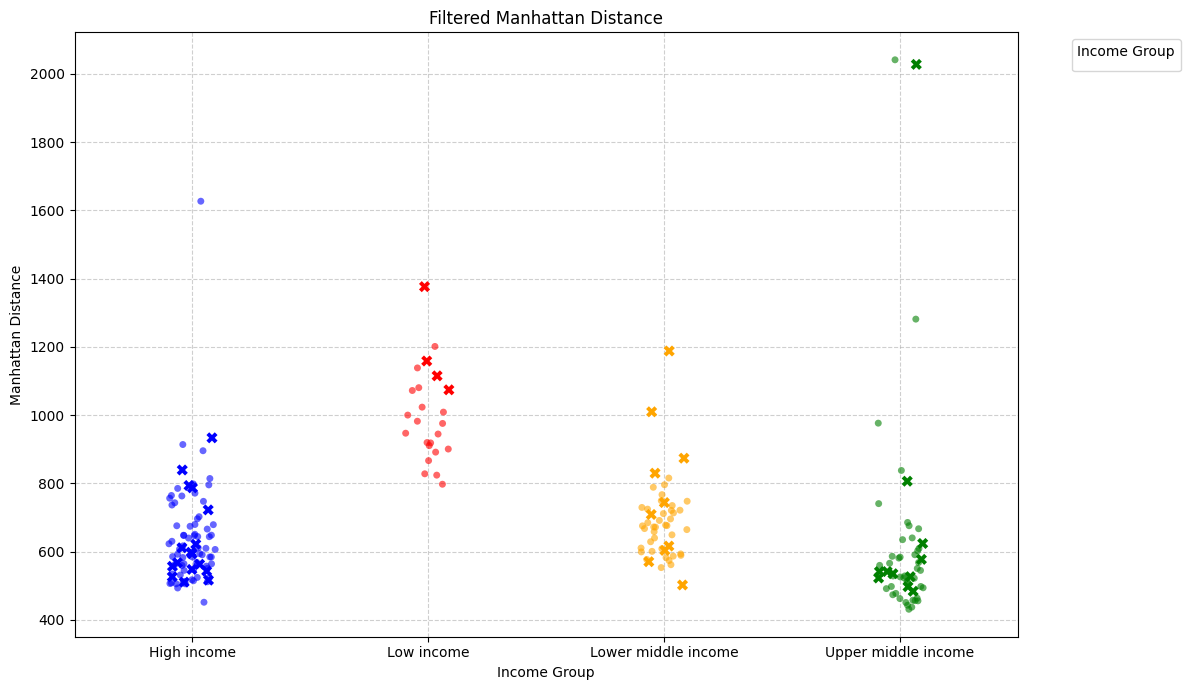

In [72]:
test_distances = np.array([
    manhattan_distance(point, initial_point_zero)
    for point in X_test
])

test_df = pd.DataFrame({
    'Manhattan Distance to Zero': test_distances,
    'Predicted_Group': np.array(predictions)
})

threshold = 10000

plot_df = plot_df[plot_df['Manhattan Distance to Zero'] <= threshold]
test_df = test_df[test_df['Manhattan Distance to Zero'] <= threshold]

plot_df = plot_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

plt.figure(figsize=(12, 7))

# Train points
sns.stripplot(
    data=plot_df,
    x='Income_Group',
    y='Manhattan Distance to Zero',
    hue='Income_Group',
    palette=custom_color_map,
    alpha=0.6,
    dodge=False
)

# Test points
sns.stripplot(
    data=test_df,
    x='Predicted_Group',
    y='Manhattan Distance to Zero',
    hue='Predicted_Group',
    palette=custom_color_map,
    marker='X',
    size=8,
    edgecolor='black',
    dodge=False,
    legend=False
)

plt.title('Filtered Manhattan Distance')
plt.xlabel('Income Group')
plt.ylabel('Manhattan Distance')

# Keep only one legend (clean)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:len(custom_color_map)], labels[:len(custom_color_map)],
           title='Income Group',
           bbox_to_anchor=(1.05, 1),
           loc='upper left')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Inference for new Observations

In [73]:
import numpy as np
import warnings

# Ensure X_train_raw and scaler are available from previous steps
if 'X_train_raw' not in locals() or 'scaler' not in locals() or 'knn' not in locals():
    print("Error: X_train_raw, scaler, or knn model not found. Please run previous cells.")
else:
    # Create an arbitrary new observation based on the mean of the training data
    new_observation_raw = X_train_raw.mean().values


    new_observation_raw[50] = new_observation_raw[50] + 100 # Add a constant

    print("\n--- Inference on a New Arbitrary Observation ---")
    print(f"Raw New Observation Sample (first 5 features): {new_observation_raw[:5]}")

    # Suppress the UserWarning regarding feature names
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        new_observation_scaled = scaler.transform(new_observation_raw.reshape(1, -1))

    print(f"Scaled New Observation Sample (first 5 features): {new_observation_scaled[0, :5]}")

    # Predict the Income_Group using the trained KNN model
    predicted_income_group = knn.predict(new_observation_scaled)
    print(f"Predicted Income Group for the new observation: {predicted_income_group[0]}")


--- Inference on a New Arbitrary Observation ---
Raw New Observation Sample (first 5 features): [3.26892979e+02 1.54475026e+02 2.20468023e+05 3.58396603e+01
 5.71339889e+06]
Scaled New Observation Sample (first 5 features): [0. 0. 0. 0. 0.]
Predicted Income Group for the new observation: Upper middle income
